Starting Notebook for playing with OpenAI Environments
======================================================
Basic starter notebook for playing with the states, actions, and rewards for the OpenAI Gym classic control environments.

# Install OpenAI Gym

In [16]:
%pip install gym
%pip install pygame

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.1/10.6 MB 3.4 MB/s eta 0:00:04
   - -------------------------------------- 0.5/10.6 MB 7.1 MB/s eta 0:00:02
   --- ------------------------------------ 1.0/10.6 MB 9.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/10.6 MB 11.4 MB/s eta 0:00:01
   --------- ------------------------------ 2.6/10.6 MB 12.6 MB/s eta 0:00:01
   ------------ --------------------------- 3.3/10.6 MB 13.2 MB/s eta 0:00:01
   -------------- ------------------------- 4.0/10.6 MB 13.3 MB/s eta 0:00:01
   ----------------- ---------------------- 4.7/10.6 MB 13.7 MB/s eta 0:00:01
   --------------------- ------------------ 5.6/10.6 MB 14.4 MB/s eta 0:00:01
   ----------------------- ---------------- 6.3/10.6 MB 14.5 MB/s eta 0:00:01
   ------------------------- -------------- 6.9/10.6 MB 14.7 MB/s eta 0:00:01
   ------

# Minimal install, if on CoLab
If you are running this locally on your laptop or desktop, then you may not need the below, but I need the below to get this to run on a remote server on CoLab (it is mostly to handle the lack of a "display" on a remote server).

In [3]:
!apt install xvfb -y
!pip install pyvirtualdisplay

'apt' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
# Creates a virtual display in CoLab. May not be necessary if locally installed.
from pyvirtualdisplay import Display
display = Display(visible=0, size=(1400, 900))
display.start()

FileNotFoundError: [WinError 2] The system cannot find the file specified

# Now for Actually Exploring Gym
If installed correctly, then the below is how you use it to explore various aspects of the RL Acrobot Environment.

In [11]:
%matplotlib inline
import gym
import numpy as np
# For Plotting:
import matplotlib
import matplotlib.pyplot as plt
# If you want degrees or radians:
import math
# If you want to randomize the states or actions:
import random

Example of Basic loading and plotting in the default state:

Starting in: [-0.07664312  0.03825886  0.03161526  0.04521357]


(-0.5, 499.5, 499.5, -0.5)

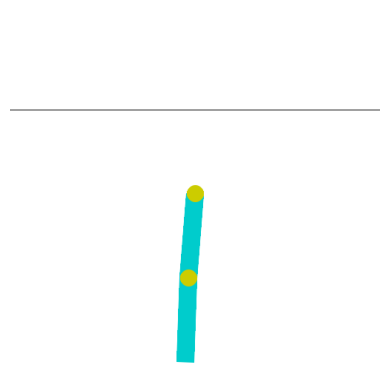

In [17]:
env = gym.make("Acrobot-v1", render_mode="rgb_array")
# Need to reset the environment to initialize it
# Resets it to a random configuration hanging down
env.reset()
# The State
# Array is: [top_theta (in rads),         bottom_theta (in_rads),
#            top_theta_dot (in rads/sec), bottom_theta_dot (in_rads/sec)]
print("Starting in:", env.env.state)
plt.imshow(env.render())
plt.axis("off")

Example of modifying the initial (reset) state to put the robot into a new state (just for testing/visualization purposes). Normally you would not be able to manipulate the state directly (you could also do this through taking actions). But, for exploring the reward function or actions, this might be useful.

Starting in: [3.14, 1.57, 0.0, 0.0]


(-0.5, 499.5, 499.5, -0.5)

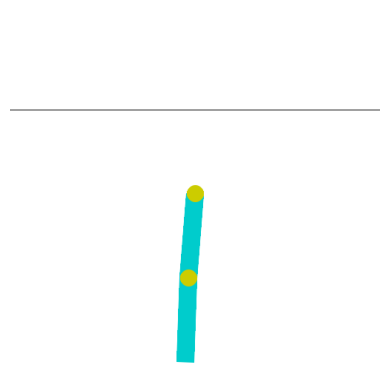

In [19]:
# Now you can set the initial state of the system, if you want to play with it
# Array is: [top_theta (in rads),         bottom_theta (in_rads),
#            top_theta_dot (in rads/sec), bottom_theta_dot (in_rads/sec)]
# Quick ref: 90 degs = 1.57 rads
## Change the below:
env.env.state = [1.57*2, 1.57, 0.0, 0.0]
# Alternatively, if you prefer degrees
# env.env.state = [math.radians(90)*2, math.radians(90), 0.0, 0.0]

print("Starting in:", env.env.state)
plt.imshow(env.render())
plt.axis("off")

Example of investigating the "before" and "after" of taking various actions. You can use this to get a sense of what different actions do to the system.

Starting in: [0.5, 0, 0.0, 0.0]


(-0.5, 499.5, 499.5, -0.5)

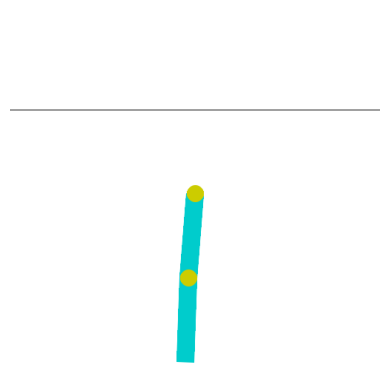

In [21]:
# Before
env.env.state = [0.5, 0, 0.0, 0.0]
# Alternatively, if you prefer degrees
# env.env.state = [math.radians(90)*2, math.radians(90), 0.0, 0.0]

print("Starting in:", env.env.state)
plt.imshow(env.render())
plt.axis("off")

Taking Action: 0
Observation: [ 0.98379767  0.17928244  0.9150346  -0.4033754   0.3135584  -0.64998865]
New State: [0.5, 0, 0.0, 0.0]
Reward: -1.0
Done: False
Info: {}
After:


(-0.5, 499.5, 499.5, -0.5)

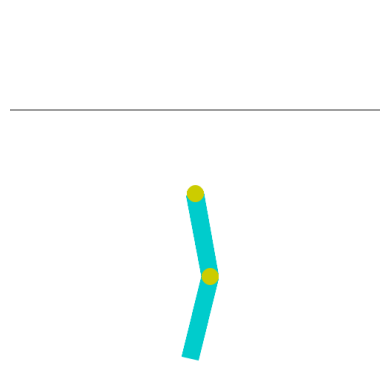

In [23]:
## Change the below to see the effect of actions:
action = 0
print("Taking Action:", action)
env.step(action) # Can be -1, 0, or +1

# Now we compute the "after" of taking that action:
observation, reward, terminated, truncated, info = env.step(action)
done = terminated or truncated
# Note that the observation provided by env.step is a little different than
# the input state:
# Input was: Angle 1, Angle 2, Ang_Vel 1, Ang_Vel 2
# But observation returns:
# Output is: ([cos(Ang.1), sin(Ang.1), 
#              cos(Ang.2), sin(Ang.2), 
#              Ang_Vel 1, Ang_Vel 2])
print("Observation:", observation)
# Compare the above with the below to see what I mean:
print("New State:", env.env.state)
# This allows you to see the "reward" of the new state in "observation"
print("Reward:", reward)
print("Done:", done)
# For Acrobot, the Info part will always be empty. You can ignore it.
# In other environments, there might be other things in here.
print("Info:", info)

print("After:")
plt.imshow(env.render())
plt.axis("off")
#env.render()

## Re-Running this cell should step through subsequent timesteps

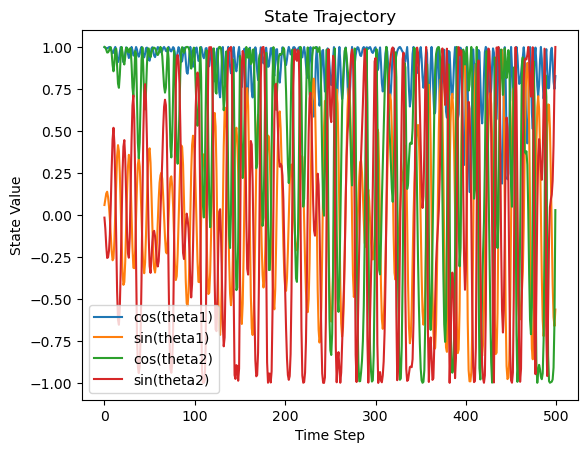

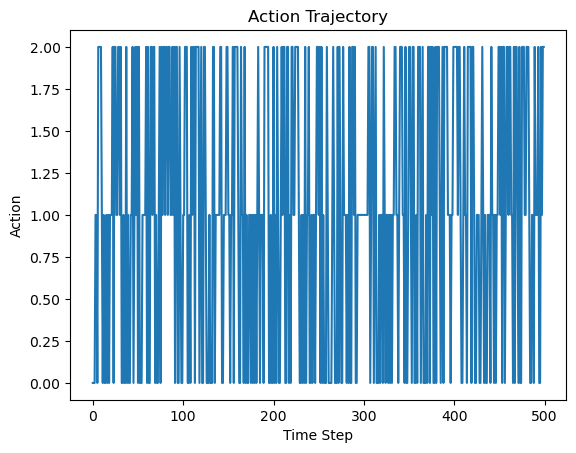

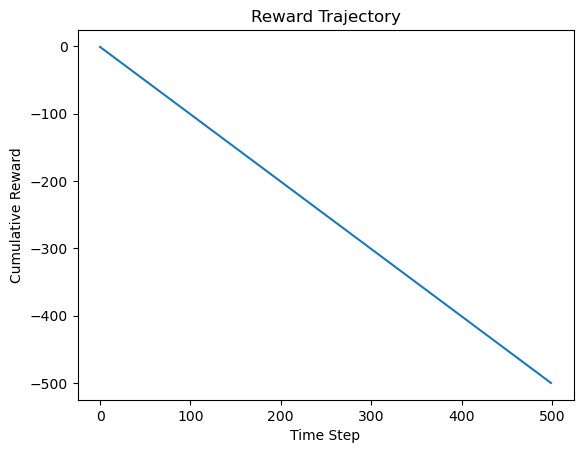

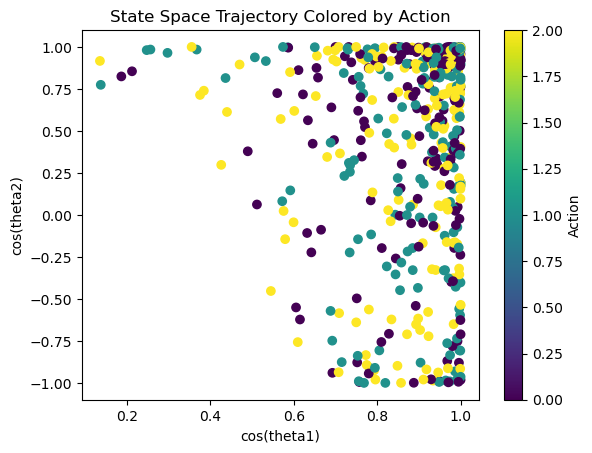

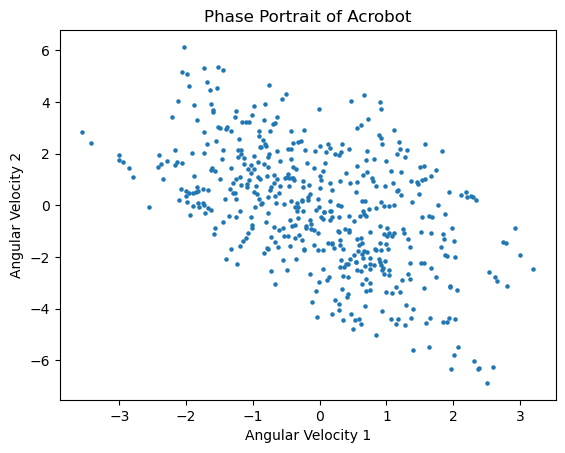

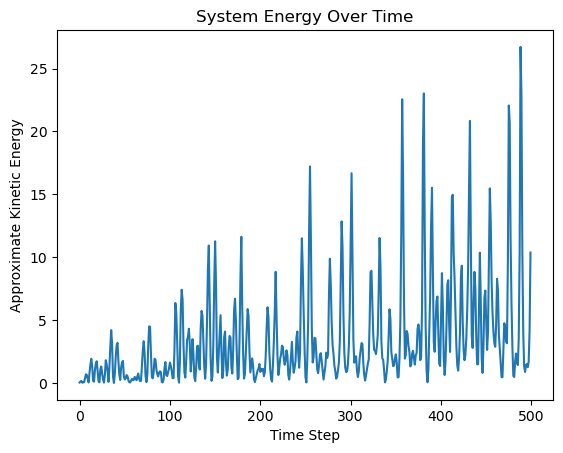

In [28]:
import gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("Acrobot-v1")

state, info = env.reset()

states = []
actions = []
rewards = []

done = False

while not done:

    action = env.action_space.sample()

    observation, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    states.append(observation)
    actions.append(action)
    rewards.append(reward)

states = np.array(states)
actions = np.array(actions)
rewards = np.array(rewards)

plt.figure()

plt.plot(states[:,0], label="cos(theta1)")
plt.plot(states[:,1], label="sin(theta1)")
plt.plot(states[:,2], label="cos(theta2)")
plt.plot(states[:,3], label="sin(theta2)")

plt.xlabel("Time Step")
plt.ylabel("State Value")
plt.title("State Trajectory")
plt.legend()

plt.show()
plt.figure()

plt.plot(actions)

plt.xlabel("Time Step")
plt.ylabel("Action")
plt.title("Action Trajectory")

plt.show()
plt.figure()

plt.plot(np.cumsum(rewards))

plt.xlabel("Time Step")
plt.ylabel("Cumulative Reward")
plt.title("Reward Trajectory")

plt.show()
plt.figure()

plt.scatter(states[:,0], states[:,2], c=actions, cmap="viridis")

plt.xlabel("cos(theta1)")
plt.ylabel("cos(theta2)")
plt.title("State Space Trajectory Colored by Action")

plt.colorbar(label="Action")

plt.show()

plt.figure()

plt.scatter(states[:,4], states[:,5], s=5)

plt.xlabel("Angular Velocity 1")
plt.ylabel("Angular Velocity 2")
plt.title("Phase Portrait of Acrobot")

plt.show()

theta1_dot = states[:,4]
theta2_dot = states[:,5]

energy = 0.5 * (theta1_dot**2 + theta2_dot**2)

plt.figure()

plt.plot(energy)

plt.xlabel("Time Step")
plt.ylabel("Approximate Kinetic Energy")
plt.title("System Energy Over Time")

plt.show()